In [1]:
# Imports
import numpy as np
import matplotlib.pyplot as plt
import importlib
import astropy.units as u

import sys
sys.path.append('/global/homes/c/cpopik/CAPPIBARAS')

import Plots, MapData
import Models.Studies as Studies

# Plot Styling
plt.style.use('dark_background')
plt.rcParams.update({
    'font.family':'serif', 'mathtext.fontset':'dejavuserif',
    'axes.grid':True, 'grid.linestyle': ':', 'grid.alpha': 0.5,
    'xtick.direction':'in', 'xtick.minor.visible': True, 'xtick.top':True,
    'ytick.direction':'in', 'ytick.minor.visible': True, 'ytick.right':True,
})

## Coulton 2024

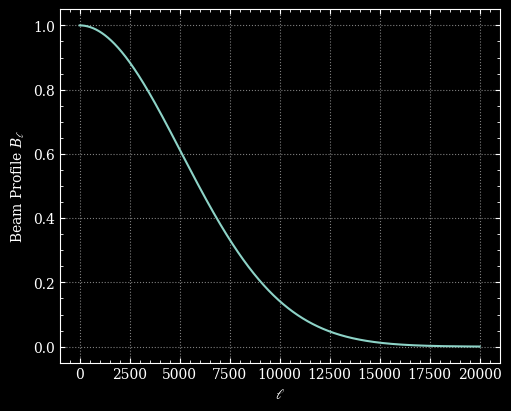

In [2]:
importlib.reload(Plots); importlib.reload(MapData)

fig, ax = plt.subplots(1, 1, figsize=(5, 4), layout='constrained')

C24 = MapData.Coulton2024()

ax.plot(C24.beam_ells, C24.beam_data)
ax.set(xlabel=r'$\ell$', ylabel=r'Beam Profile $B_\ell$')

plt.show()

## Naess 2020

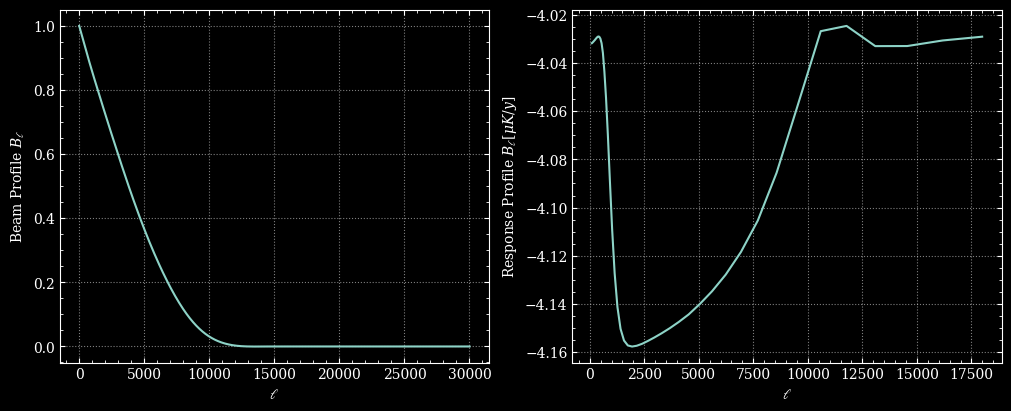

In [3]:
importlib.reload(Plots); importlib.reload(MapData)

fig, axs = plt.subplots(1, 2, figsize=(10, 4), layout='constrained')

N20 = MapData.Naess2020(freq='090')
N20.get_beam()
N20.get_resp()

axs[0].plot(N20.beam_ells, N20.beam_data)
axs[0].set(xlabel=r'$\ell$', ylabel=r'Beam Profile $B_\ell$')

axs[1].plot(N20.resp_ells, N20.resp_data)
axs[1].set(xlabel=r'$\ell$', ylabel=r'Response Profile $B_\ell [\mu K/y]$')

plt.show()

plt.show()

# Distributions

In [2]:
import Models.Data as Data
importlib.reload(Data)

Jenna = Data.Jenna_Catalog({'masstype':'Mstar'})
White2022 = Data.White2022({'zbin':'z1'})
Zhou2023 = Data.Zhou2023({'zbin':'z1', 'sample':'main', 'hemisphere':'combined'})
Liu2025 = Data.Liu2025({'zbin':'z1', 'ACTDR':'DR6', 'dp':'dBeta', 'Beta':'1.2', 'TCIB':'10.7'})
Guachalla2025 = Data.RiedGuachalla2025({'bin':'z_1'})
Gao = Data.Gao2023({'sample':'LRG', 'model':'ELG'})
Amodeo = Data.Amodeo2021({'model':'GNFW', 'prof':'Amodeo', 'units':'cgs'})
CMASSDR10 = Data.SDSSBOSS({'galaxy':'CMASS', 'DR':'DR10', 'group':'portsmouth', 'template':'passive', 'IMF':'krou'})

AttributeError: 'Jenna_Catalog' object has no attribute 'dNdq1dq2_cat'

In [ ]:
RG25 = Data.RiedGuachalla2025(bin='mass_1')
logMs, N = RG25.get_dist('N_logMs', dlogMs=0.05)

In [1]:
fig, axs = plt.subplots(2, 2, figsize=(15, 10), layout='constrained', sharex='col')
axs=axs.flatten()

import Models.Data as Data
import Models.Studies as Studies
importlib.reload(Studies)
importlib.reload(Data)

RG25 = Data.RiedGuachalla2025(bin='all')

for mod, name in zip([RG25], ['Ried-Guachalla 2025']):
    logMs, dNdlogMs = mod.get_dist('dNdlogMs')
    axs[0].scatter(logMs, dNdlogMs, alpha=0.5, label=name)
    logMs, N_logMs = mod.get_dist('N_logMs')
    axs[1].scatter(logMs, N_logMs, alpha=0.5, label=name)
    # logMs, dndz = mod.get_zdist('dndlogMs')
    # axs[2].scatter(logMs, dndz, alpha=0.5, label=name)
    # logMs, n = mod.get_zdist('n_logMs')
    # axs[3].scatter(logMs, n, alpha=0.5, label=name)

axs[0].set(ylabel=r'$ \frac{dN}{d\text{log}M_*}$'); axs[0].legend()
axs[1].set(ylabel=r'$ N$'); axs[1].legend()
axs[2].set(xlabel=r'$ \log M_*$', ylabel=r'$\frac{dn}{d\text{log}M_*}$'); axs[2].legend()
axs[3].set(xlabel=r'$ \log M_*$', ylabel=r'$n$'); axs[3].legend()
plt.show()


KeyboardInterrupt



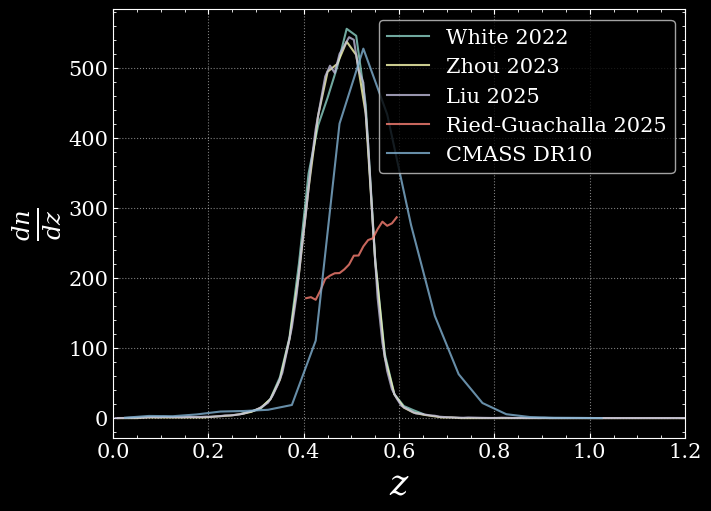

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(7, 5), layout='constrained')

ax.plot(White2022.zs, White2022.dndz, alpha=0.8, label='White 2022')
ax.plot(Zhou2023.zs, Zhou2023.dndz, alpha=0.8, label='Zhou 2023')
ax.plot(Liu2025.zs, Liu2025.dndz, alpha=0.8, label='Liu 2025')
ax.plot(Guachalla2025.zs, Guachalla2025.dndz, alpha=0.8, label='Ried-Guachalla 2025')
ax.plot(CMASSDR10.zs, CMASSDR10.dndz, alpha=0.8, label='CMASS DR10')

ax.set(xlabel=r'$z$', ylabel=r'$ \frac{dn}{dz}$', xlim=(0, 1.2)); ax.legend()
plt.show()

## Mass

In [ ]:
import Models.Data as Data
importlib.reload(Data)

Amodeo = Data.Amodeo2021({'model':'GNFW', 'prof':'Amodeo', 'units':'cgs'})

Guachalla2025 = Data.RiedGuachalla2025({'bin':'z_1'})

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


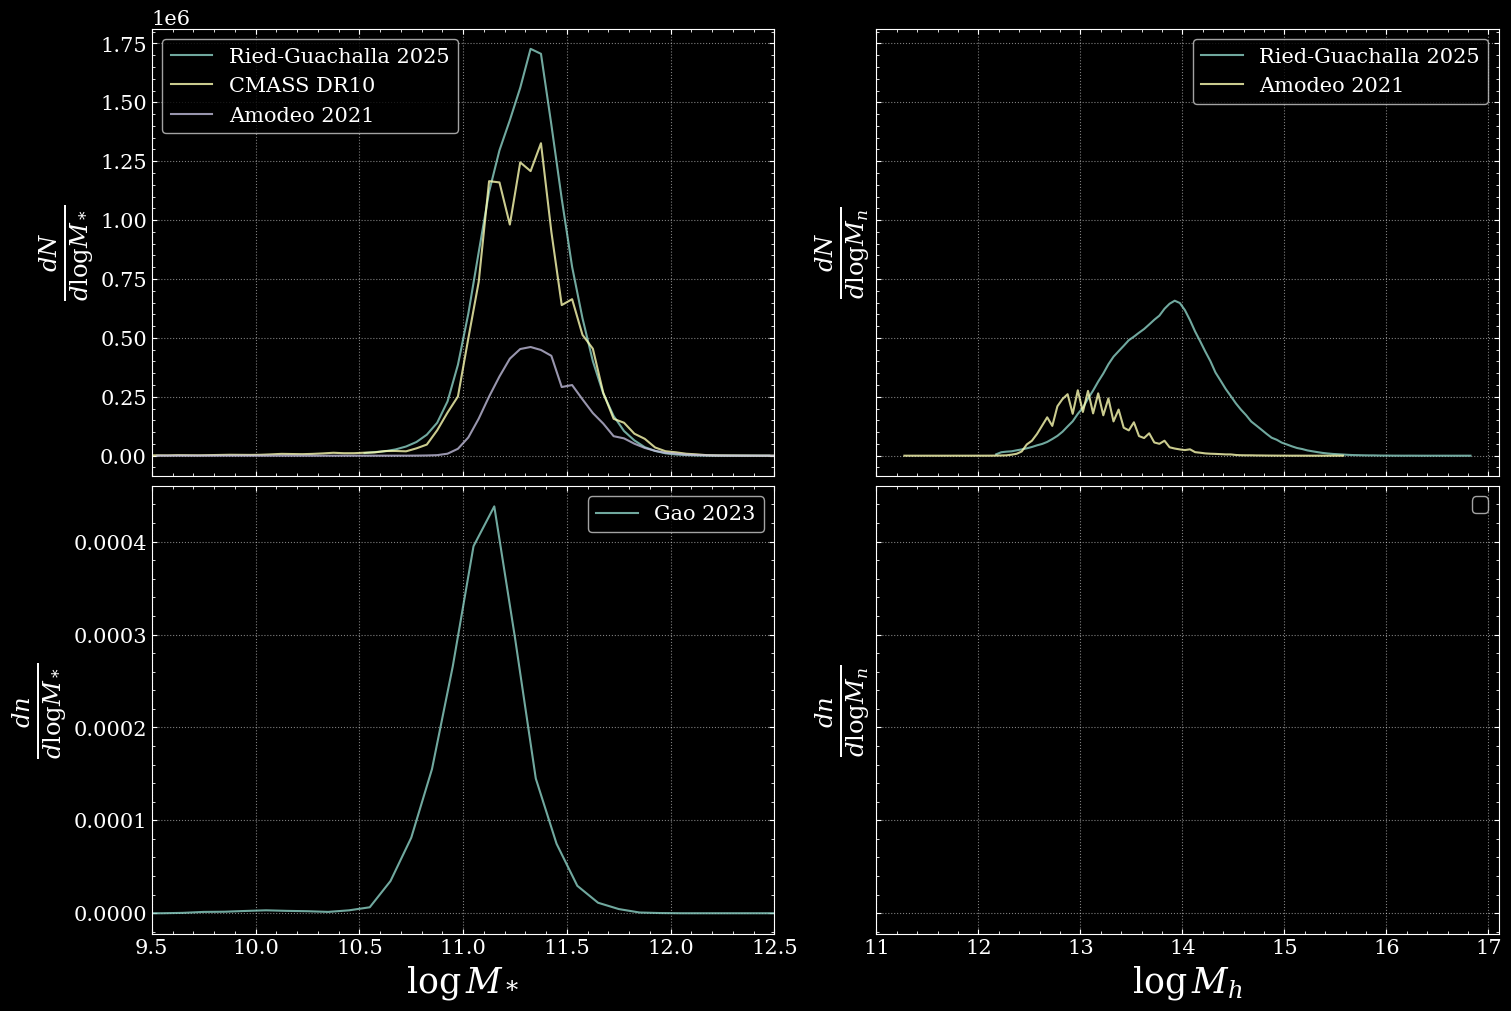

In [ ]:
fig, axs = plt.subplots(2, 2, figsize=(15, 10), layout='constrained', sharex='col', sharey='row')
axs=axs.flatten()

axs[0].plot(Guachalla2025.logMstar, Guachalla2025.dNdlogMstar, alpha=0.8, label='Ried-Guachalla 2025')
axs[1].plot(Guachalla2025.logMhalo, Guachalla2025.dNdlogMhalo, alpha=0.8, label='Ried-Guachalla 2025')

axs[0].plot(CMASSDR10.logMstar, CMASSDR10.dNdlogMstar, alpha=0.8, label='CMASS DR10')

axs[0].plot(Amodeo.logMstar, Amodeo.dNdlogMstar, alpha=0.8, label='Amodeo 2021')
axs[1].plot(Amodeo.logMhalo, Amodeo.dNdlogMhalo, alpha=0.8, label='Amodeo 2021')

axs[2].plot(Gao.logMstars, Gao.dndlogMstar[0], alpha=0.8, label='Gao 2023')

axs[0].set(ylabel=r'$ \frac{dN}{d\text{log}M_*}$', xlim=(9.5, 12.5)); axs[0].legend()
axs[1].set(ylabel=r'$ \frac{dN}{d\text{log}M_n}$'); axs[1].legend()
axs[2].set(xlabel=r'$ \log M_*$', ylabel=r'$ \frac{dn}{d\text{log}M_*}$'); axs[2].legend()
axs[3].set(xlabel=r'$ \log M_h$', ylabel=r'$ \frac{dn}{d\text{log}M_n}$'); axs[3].legend()
plt.show()

# Checked

## Liu 2025

z1 ndens=81.9 1 / deg2, calc as 82.01 1 / deg2
z2 ndens=148.1 1 / deg2, calc as 148.18 1 / deg2
z3 ndens=162.4 1 / deg2, calc as 162.52 1 / deg2
z4 ndens=148.3 1 / deg2, calc as 148.50 1 / deg2


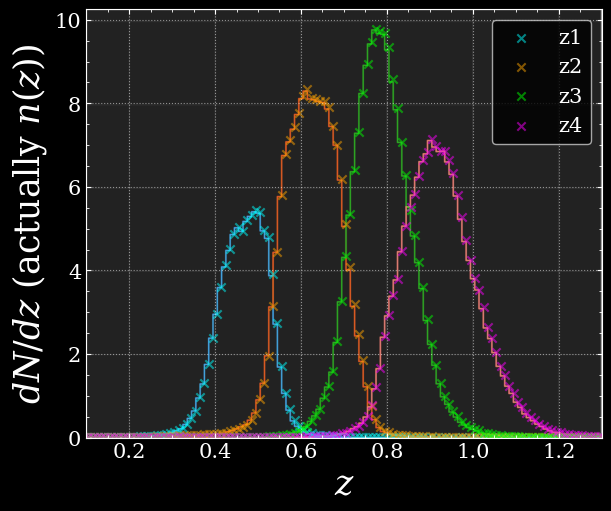

In [3]:
importlib.reload(Plots); importlib.reload(Data)
fig, ax = Plots.Liu2025().Fig2()

for zbin, color in zip(['z1', 'z2', 'z3', 'z4'], ['cyan', 'orange', 'lime', 'magenta']):
    L25 = Data.Liu2025(zbin=zbin)
    z, n = L25.get_dist('n_z')
    print(f'{L25.zbin} ndens={L25.nGal}, calc as {np.trapz(n/L25.dz, z):.2f}')
    ax.scatter(z, n, alpha=0.5, marker='x', c=color, label=f'{L25.zbin}')

ax.legend()
plt.show()

## Ried-Guachalla 2025

z_1 Ngal=195877, calc as 179660
z_2 Ngal=235620, calc as 271326
z_3 Ngal=235620, calc as 210497
z_4 Ngal=96346, calc as 93843


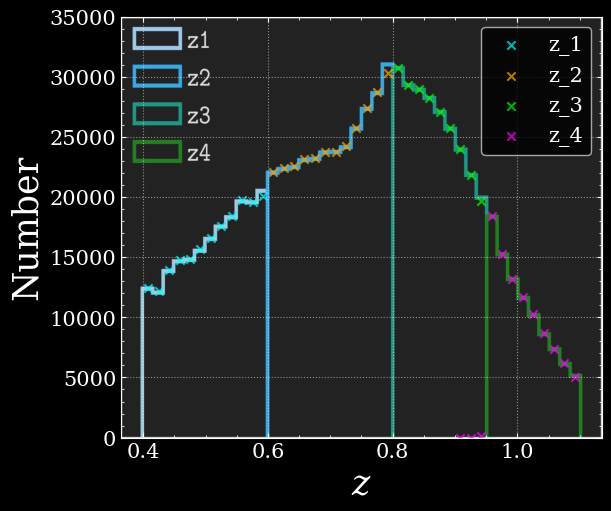

In [4]:
importlib.reload(Plots); importlib.reload(Data)
fig, ax = Plots.RiedGuachalla2025().Fig2()

for bin, color in zip(['z_1', 'z_2', 'z_3', 'z_4'], ['cyan', 'orange', 'lime', 'magenta']):
    RG25 = Data.RiedGuachalla2025(bin=bin)
    z, N = RG25.get_dist('N_z', dz=0.0167)
    print(f'{RG25.bin} Ngal={RG25.NGal}, calc as {np.trapz(N/RG25.dz, z):.0f}')
    ax.scatter(z, N, alpha=0.7, marker='x', c=color, label=f'{RG25.bin}')

ax.legend()
plt.show()

mass_1 Ngal=244932, calc as 212247
mass_2 Ngal=320914, calc as 285314
mass_3 Ngal=194037, calc as 144324
mass_4 Ngal=53997, calc as 43973


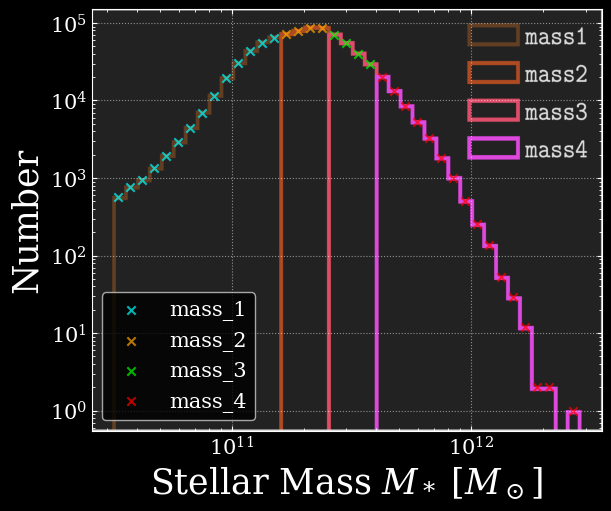

In [5]:
importlib.reload(Plots); importlib.reload(Data)
fig, ax = Plots.RiedGuachalla2025().Fig3()

for bin, color in zip(['mass_1', 'mass_2', 'mass_3', 'mass_4'], ['cyan', 'orange', 'lime', 'red']):
    RG25 = Data.RiedGuachalla2025(bin=bin)
    logMs, N = RG25.get_dist('N_logMs', dlogMs=0.05)
    print(f'{RG25.bin} Ngal={RG25.NGal}, calc as {np.trapz(N/RG25.dlogMs, logMs):.0f}')
    ax.scatter(10**logMs, N, alpha=0.7, marker='x', c=color, label=f'{RG25.bin}')

ax.legend(loc='lower left')
plt.show()

## Gao 2023

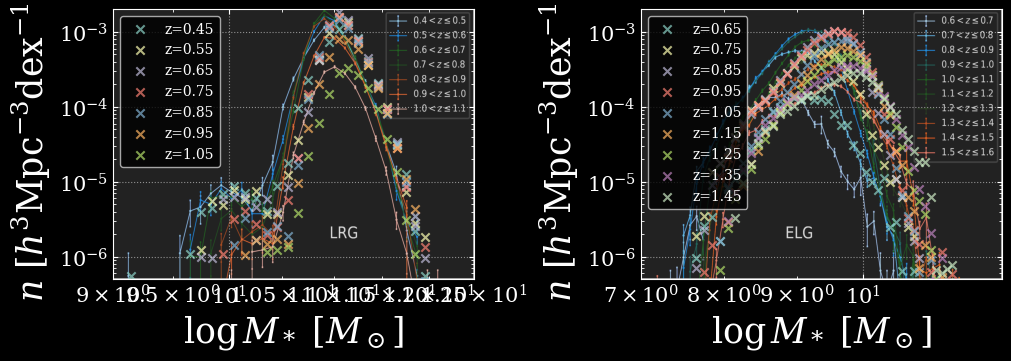

In [6]:
importlib.reload(Plots); importlib.reload(Data)
fig, axs = Plots.Gao2023().Fig2()

G23= Data.Gao2023(sample='LRG')
G23.make_zMsdists()
for i, z in enumerate(G23.z):
    axs[0].scatter(G23.logMs, G23.n_logMs_z_h3[i], alpha=0.7, marker='x', label=f'z={z:.2f}')

G23 = Data.Gao2023(sample='ELG')
G23.make_zMsdists()
for i, z in enumerate(G23.z):
    axs[1].scatter(G23.logMs, G23.n_logMs_z_h3[i], alpha=0.7, marker='x', label=f'z={z:.2f}')

axs[0].legend(fontsize=10, loc='upper left'); axs[1].legend(fontsize=10, loc='upper left')
plt.show()

In [7]:
G23= Data.Gao2023(sample='LRG')
G23.make_zMsdists()
mcut = (G23.logMs_df>=11.1) & (G23.logMs_df<=11.9)
zcut = (G23.z_df>=0.8) & (G23.z_df<=1.0)
N_z_logMs = G23.dNdzdlogMs_df*(G23.z_df[1]-G23.z_df[0])*(G23.logMs_df[1]-G23.logMs_df[0]) * u.dex**2
print(G23.z_df[zcut], G23.logMs_df[mcut])
N = 13906+4834+957+124
print(np.sum(N_z_logMs[:,mcut][zcut], axis=0).reshape(-1, 2).sum(axis=1))
print(f'{N:.3e}', f'{np.sum(N_z_logMs[:,mcut][zcut]):.3e}')

[0.85 0.95] [11.15 11.25 11.35 11.45 11.55 11.65 11.75 11.85]
[13820.64802317  4819.76390403   958.53731266   125.9293599 ]
1.982e+04 1.972e+04


In [ ]:
G23= Data.Gao2023(sample='LRG')
G23.make_zMsdists(dlogMs=0.001, dz=0.01)
mcut = (G23.logMs>=11.1) & (G23.logMs<=11.9)
zcut = (G23.z>=0.8) & (G23.z<=1.0)
N = 13906+4834+957+124
print(f'{N:.3e}', f'{np.sum(G23.N_z_logMs[:,mcut][zcut]):.3e}')
print(f'{np.trapz(G23.dNdz, G23.z*u.dex):.3e}', f'{np.sum(G23.N_z_logMs):.3e}')

G23= Data.Gao2023(sample='ELG')
G23.make_zMsdists(dlogMs=0.001, dz=0.01)
mcut = (G23.logMs>=8.5) & (G23.logMs<=10.5)
zcut = (G23.z>=0.8) & (G23.z<=1.0)
N=9481+29764+34155+6583
print(f'{N:.3e}', f'{np.sum(G23.N_z_logMs[:,mcut][zcut]):.3e}')
print(f'{np.trapz(G23.dNdz, G23.z*u.dex):.3e}', f'{np.sum(G23.N_z_logMs):.3e}')

# All

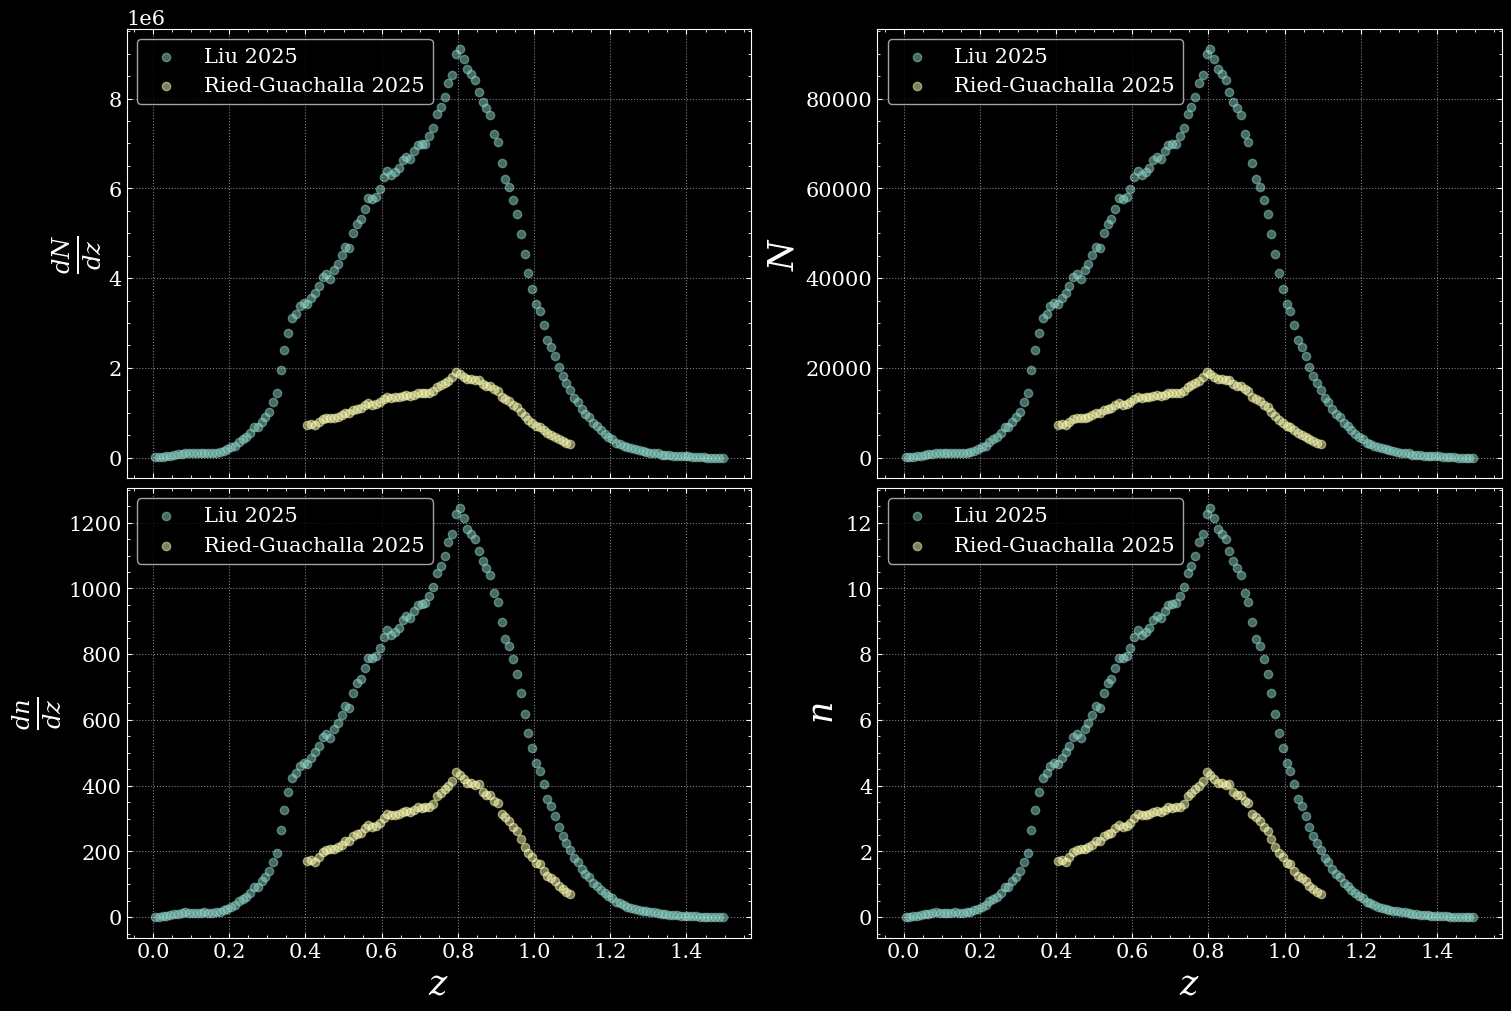

In [23]:
importlib.reload(Studies); importlib.reload(Data)

fig, axs = plt.subplots(2, 2, figsize=(15, 10), layout='constrained', sharex='col')
axs=axs.flatten()

L25 = Data.Liu2025(zbin='all')
RG25 = Data.RiedGuachalla2025(bin='all')

for mod, name in zip([L25, RG25], ['Liu 2025', 'Ried-Guachalla 2025']):
    z, dNdz = mod.get_dist('dNdz')
    axs[0].scatter(z, dNdz, alpha=0.5, label=name)
    z, N = mod.get_dist('N_z')
    axs[1].scatter(z, N, alpha=0.5, label=name)
    z, dndz = mod.get_dist('dndz')
    axs[2].scatter(z, dndz, alpha=0.5, label=name)
    z, n = mod.get_dist('n_z')
    axs[3].scatter(z, n, alpha=0.5, label=name)

axs[0].set(ylabel=r'$\frac{dN}{dz}$'); axs[0].legend()
axs[1].set(ylabel=r'$N$'); axs[1].legend()
axs[2].set(xlabel=r'$z$', ylabel=r'$\frac{dn}{dz}$'); axs[2].legend()
axs[3].set(xlabel=r'$z$', ylabel=r'$n$'); axs[3].legend()
plt.show()

# Unchecked

## Coulton 2024

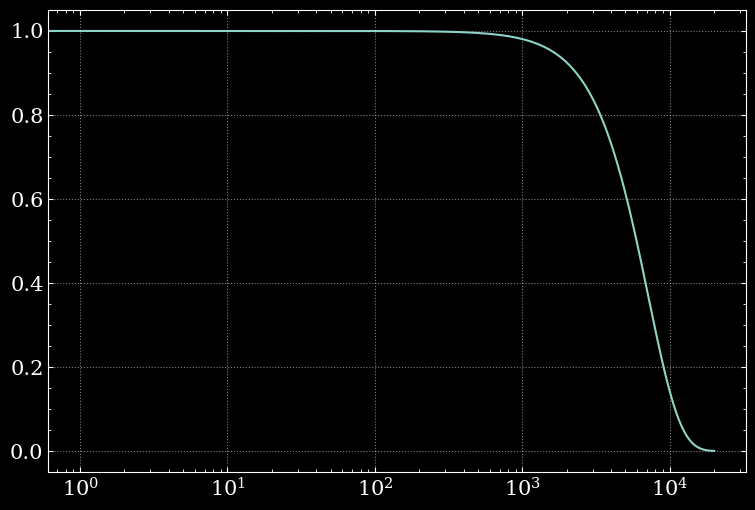

In [16]:
importlib.reload(Plots); importlib.reload(Data)

ells, beam = Data.Coulton2024().get_beam()
plt.plot(ells, beam)
plt.xscale('log')

## Ried-Guachalla 2025

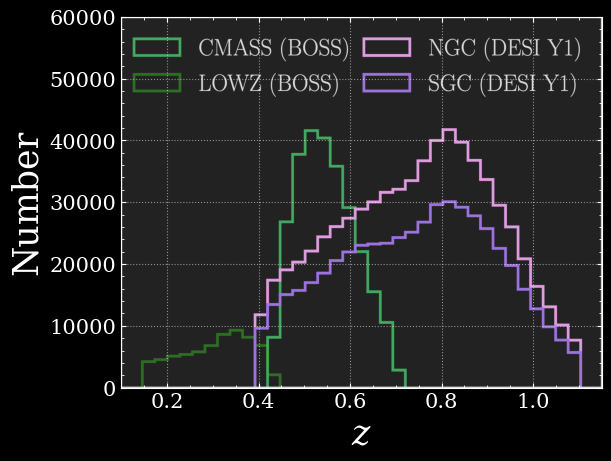

In [120]:
import Plots
importlib.reload(Plots)

fig, ax = Plots.RiedGuachalla2025().Fig20()

## Yuan 2023

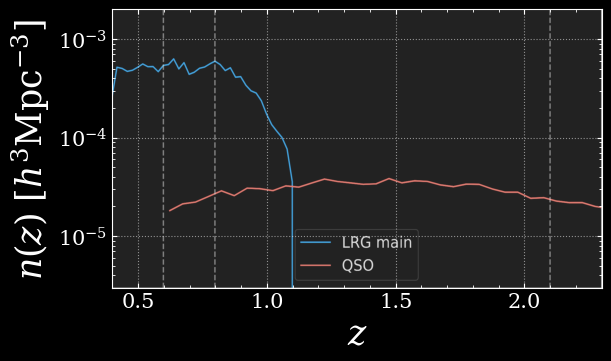

In [132]:
import Plots
importlib.reload(Plots)

fig, ax = Plots.Yuan2023().Fig1()

## Schaan 2021

In [58]:
thing = np.loadtxt('/global/homes/c/cpopik/CAPPIBARAS/Data/Schaan2021/catalog.txt')
# 0:RA, 1:DEC, 2:z, 18:?, 20-:?

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


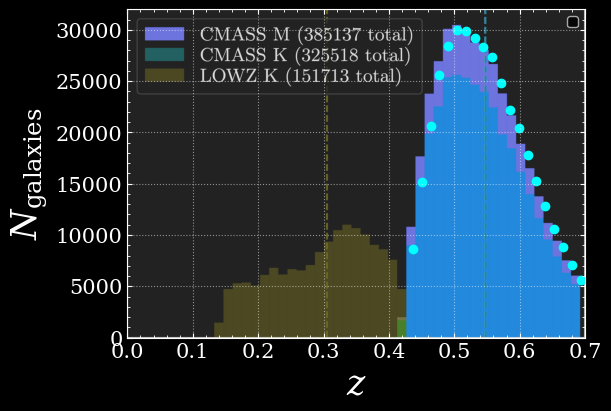

In [76]:
fig, ax = Plots.Schaan2021().Fig2()

import Data
importlib.reload(Data)

y, x = np.histogram(thing[:,2], bins=20)
ax.scatter((x[1:]+x[:-1])/2, y/2, c='cyan')

# dz=0.7/49

# CMASSDR10 = Data.SDSSBOSS({'galaxy':'CMASS', 'DR':'DR10', 'group':'portsmouth', 'template':'passive', 'IMF':'krou'})
# dNdz, z = CMASSDR10.get_dNdz(dz)
# ax.scatter(z, dNdz*CMASSDR10.dz, label=f'CMASS K {np.trapz(dNdz, z*u.dex)}')

# LOWZDR10 = Data.SDSSBOSS({'galaxy':'LOWZ', 'DR':'DR10', 'group':'portsmouth', 'template':'passive', 'IMF':'krou'})
# dNdz, z = LOWZDR10.get_dNdz(dz)
# ax.scatter(z, dNdz*dz, label=f'LOWZ K {np.trapz(dNdz, z*u.dex)}')

# CMASSDR12 = Data.SDSSBOSS({'galaxy':'CMASS', 'DR':'DR12', 'group':'portsmouth', 'template':'passive', 'IMF':'krou'})
# dNdz, z = CMASSDR12.get_dNdz(dz)
# ax.scatter(z, dNdz*dz, label=f'CMASS M {np.trapz(dNdz, z*u.dex)}')

ax.legend(fontsize=10)
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


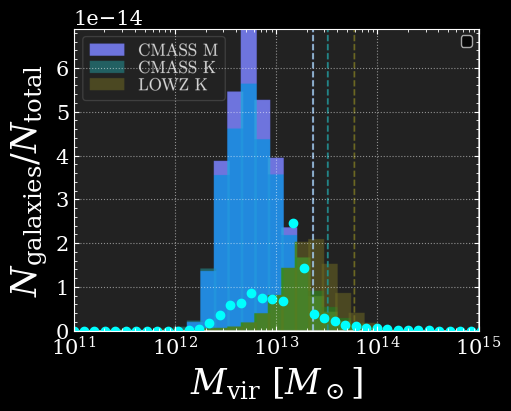

In [120]:
fig, ax = Plots.Schaan2021().Fig3()

y, x = np.histogram(np.log10(thing[:,20]), bins=50)
ax.scatter(10**((x[1:]+x[:-1])/2)*0.7, y/thing.shape[0]/1e13, c='cyan')

ax.legend(fontsize=10)
plt.show()

/tmp/ipykernel_1668614/622001043.py:7: RuntimeWarning: divide by zero encountered in divide
  ax.plot(np.pi/ell, beam/beam[0])


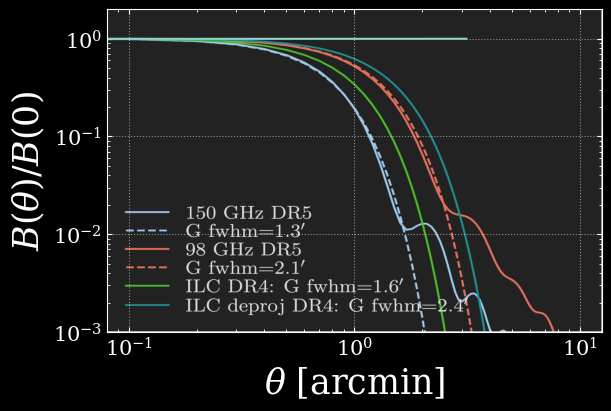

In [77]:
fig, ax = Plots.Schaan2021().Fig5()

import Data
importlib.reload(Data)

ell, beam = Data.Schaan2021(freq='150').get_beam()
ax.plot(np.pi/ell, beam/beam[0])

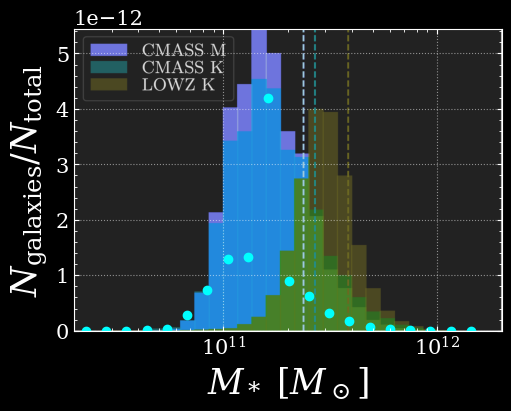

In [ ]:
import Plots
importlib.reload(Plots)

fig, ax = Plots.Schaan2021().Fig31()

y, x = np.histogram(np.log10(thing[:,18]), bins=50)
ax.scatter(10**((x[1:]+x[:-1])/2)*0.7, y/thing.shape[0]/1e11, c='cyan')


## Kusiak 2022

In [9]:
import Data
importlib.reload(Data)

K22 = Data.Kusiak2022({'sample':'Red'})
K22.make_zdists()

AttributeError: 'Kusiak2022' object has no attribute 'zs_df'

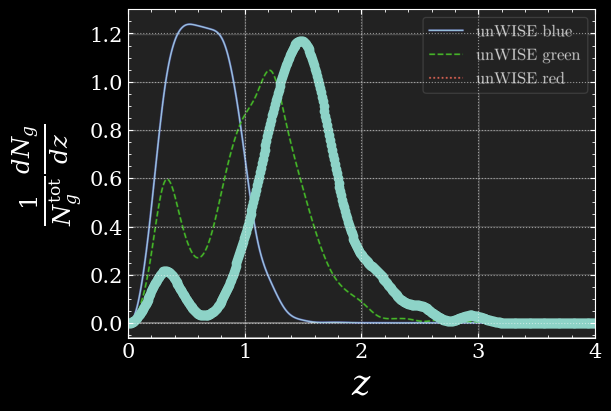

In [ ]:
fig, ax = Plots.Kusiak2022().Fig2()

ax.scatter(z, dNdz_norm)

In [ ]:
/global/homes/c/cpopik/Data/Kusiak2022/normalised_dndz_cosmos_0.txt

AttributeError: 'Kusiak2022' object has no attribute 'z'

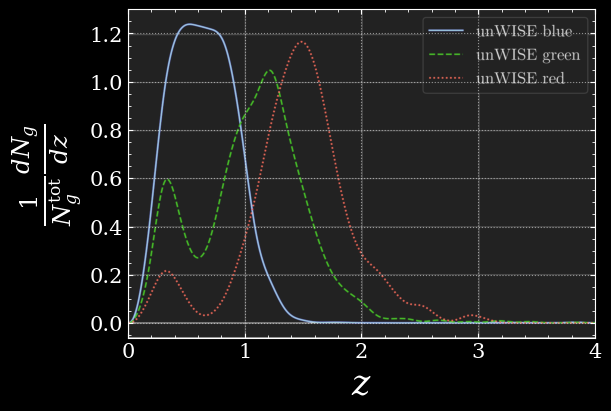

In [13]:
importlib.reload(Plots); importlib.reload(Data)

fig, ax = Plots.Kusiak2022().Fig2()


Kusiak2022 = Data.Kusiak2022({'sample':'Red'})
# zs, dNdz_norm
ax.scatter(Kusiak2022.z, Kusiak2022.dNdz_norm)

plt.show()

In [ ]:
thing = np.genfromtxt('/global/homes/c/cpopik/Data/Kusiak2022/normalised_dndz_cosmos_2.txt').T

plt.plot(thing[0], thing[1])